# Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam

## Load function of the data

In [21]:
def load_data():
    fn='Data/train_signs.h5'
    train_data=h5py.File(fn, "r")
    X_train=np.array(train_data["train_set_x"][:])
    Y_train=np.array(train_data["train_set_y"][:])
    fn='Data/test_signs.h5'
    test_data=h5py.File(fn, "r")
    X_test=np.array(test_data["test_set_x"][:])
    Y_test=np.array(test_data["test_set_y"][:])
    
    classes=np.array(test_data["list_classes"][:])
    Y_train=Y_train.reshape((1, Y_train.shape[0]))
    Y_test=Y_test.reshape((1, Y_test.shape[0]))
    return X_train, Y_train, X_test, Y_test, classes

## Load data

In [22]:
train_data, train_labels, test_data, test_labels, classes = load_data()
X_train_norm = train_data / 255.0
X_test_norm = test_data / 255.0
Y_train_norm = train_labels.T
Y_test_norm = test_labels.T

## Base model

In [23]:
base_model=Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(6, activation='softmax')
])

base_model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

base_history=base_model.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.2000 - loss: 2.1133 - val_accuracy: 0.1750 - val_loss: 1.7109
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2963 - loss: 1.7051 - val_accuracy: 0.3417 - val_loss: 1.6194
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3111 - loss: 1.6496 - val_accuracy: 0.3917 - val_loss: 1.5860
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3519 - loss: 1.6043 - val_accuracy: 0.4917 - val_loss: 1.5405
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4056 - loss: 1.5538 - val_accuracy: 0.4417 - val_loss: 1.5296
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4028 - loss: 1.5250 - val_accuracy: 0.5250 - val_loss: 1.4556
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4259 - loss: 1.4848 - val_accuracy: 0.5583 - val_loss: 1.4234
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4750 - loss: 1.4270 - val_accuracy: 0.4833 - v

## deep model

In [24]:
deep_model=Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

deep_model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

deep_history=deep_model.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.1704 - loss: 1.9572 - val_accuracy: 0.1750 - val_loss: 1.7960
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1898 - loss: 1.8441 - val_accuracy: 0.2083 - val_loss: 1.7741
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1907 - loss: 1.8125 - val_accuracy: 0.2417 - val_loss: 1.7828
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1972 - loss: 1.7944 - val_accuracy: 0.2583 - val_loss: 1.7703
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2065 - loss: 1.7825 - val_accuracy: 0.2917 - val_loss: 1.7766
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2056 - loss: 1.7860 - val_accuracy: 0.2917 - val_loss: 1.7550
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2102 - loss: 1.7803 - val_accuracy: 0.1583 - val_loss: 1.7732
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2000 - loss: 1.7785 - val_accuracy: 0.2083 - v

## Model with tanh activation

In [25]:
tanh_model=Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='tanh'),
    Dropout(0.2),
    Dense(128, activation='tanh'),
    Dropout(0.2),
    Dense(64, activation='tanh'),
    Dense(6, activation='softmax')
])

tanh_model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

tanh_history=tanh_model.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.1694 - loss: 1.8982 - val_accuracy: 0.1667 - val_loss: 1.7912
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.1694 - loss: 1.8736 - val_accuracy: 0.1750 - val_loss: 1.7780
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.1648 - loss: 1.8463 - val_accuracy: 0.2167 - val_loss: 1.7808
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.1954 - loss: 1.8372 - val_accuracy: 0.2000 - val_loss: 1.7666
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.1713 - loss: 1.8313 - val_accuracy: 0.2333 - val_loss: 1.7566
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2019 - loss: 1.8193 - val_accuracy: 0.1833 - val_loss: 1.7430
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2176 - loss: 1.7807 - val_accuracy: 0.2917 - val_loss: 1.7110
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.2046 - loss: 1.7733 - val_accuracy: 0.2500 - v

## Model without dropout

In [26]:
model_wno_dropout=Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model_wno_dropout.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history_wno_dropout=model_wno_dropout.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.1852 - loss: 1.8340 - val_accuracy: 0.1833 - val_loss: 1.7646
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2046 - loss: 1.7682 - val_accuracy: 0.3750 - val_loss: 1.6890
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3259 - loss: 1.6794 - val_accuracy: 0.3667 - val_loss: 1.6376
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3889 - loss: 1.5970 - val_accuracy: 0.3417 - val_loss: 1.6615
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3935 - loss: 1.5377 - val_accuracy: 0.3333 - val_loss: 1.5732
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4102 - loss: 1.5060 - val_accuracy: 0.3750 - val_loss: 1.5519
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4741 - loss: 1.4229 - val_accuracy: 0.3833 - val_loss: 1.4747
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4880 - loss: 1.3900 - val_accuracy: 0.4333 - v

## Results

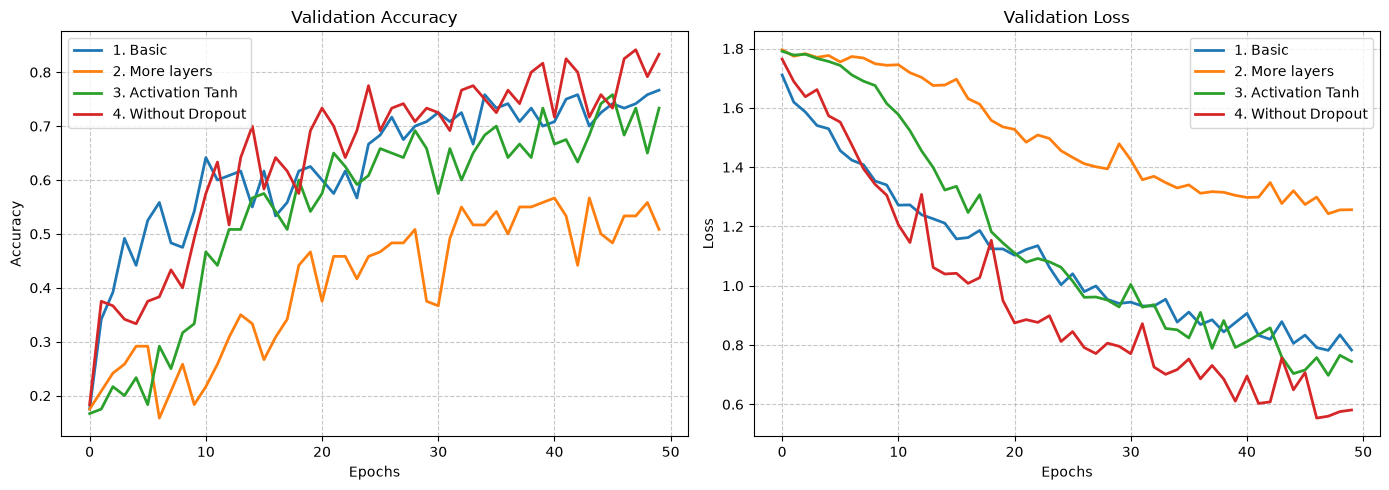


| Model                     | Accuracy (Train) | Accuracy (Test) |
| 1. Basic                  |       73.80%      |      76.67%      |
| 2. More layers            |       39.17%      |      50.83%      |
| 3. Activation Tanh        |       66.94%      |      73.33%      |
| 4. Without Dropout        |       87.31%      |      83.33%      |


In [27]:
histories = {
    "1. Basic": globals().get('base_history') or base_model.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1),
    "2. More layers": globals().get('deep_history') or deep_model.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1),
    "3. Activation Tanh": globals().get('tanh_history') or tanh_model.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1),
    "4. Without Dropout": globals().get('history_wno_dropout') or model_wno_dropout.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1)
}

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=name, linewidth=2)
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
for name, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=name, linewidth=2)
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
print("\n" + "="*70)
print(f"| {'Model':<25} | {'Accuracy (Train)':<16} | {'Accuracy (Test)':<15} |")
print("="*70)
for name, hist in histories.items():
    train_acc = hist.history['accuracy'][-1] * 100
    val_acc = hist.history['val_accuracy'][-1] * 100
    print(f"| {name:<25} | {train_acc:>11.2f}%      | {val_acc:>10.2f}%      |")
    
print("="*70)

## Висновок

З результатів видно, що модель без Dropout (0.0) дала найвищу точність і на тренувальних, і на тестових даних. Водночас є підстави вважати, що вона могла перенавчитися.

Найбільш збалансованим варіантом виглядає базова модель: вона показала хорошу якість на тестовій вибірці та не демонструє явних ознак перенавчання.